# Mesoscale Flow and the Biological Transition Zone

In [2]:
from smode_import import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
def gridlines(gl,delta=0.4):
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    import matplotlib.ticker as mticker
    
    gl.xlines = False
    gl.ylines = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180,180,delta))
    gl.ylocator = mticker.FixedLocator(np.arange(-90,90,delta))

    gl.top_labels = False
    gl.right_labels = False
    
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    #gl.xlabel_style = {'size': 15, 'color': 'gray'}
    #gl.xlabel_style = {'color': 'red', 'weight': 'bold'}

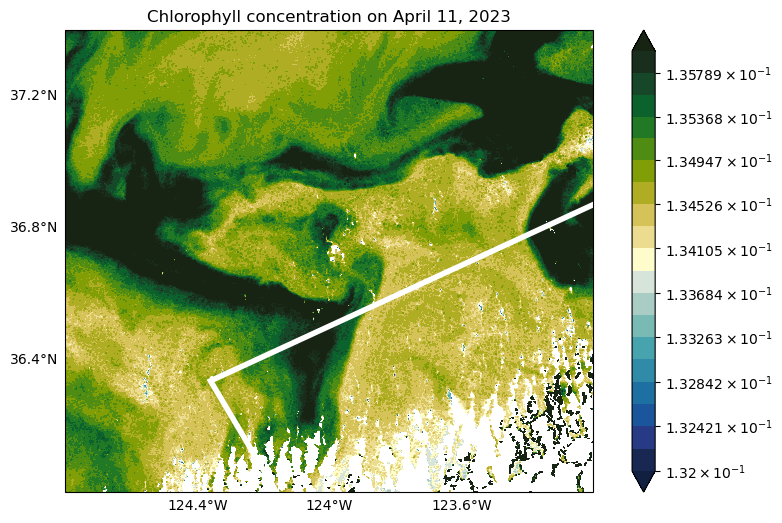

In [23]:
# Plot EKE with Chl
from parula import parula
import matplotlib
cmap='ocean_r'#parula

#mat = scipy.io.loadmat('/Users/elise/data/SMODE-data/Sentinel3A/2023Apr22_sen3.mat')
path='~/data/SMODE-data/Sentinel3A/IOP2/'
sen3=xr.open_dataset(path+'Sentinel_3A_20230411T182956Z.nc')
sen3['CHL_OC4ME'] = sen3.CHL_OC4ME.where(sen3.CHL_OC4ME <= 100)
sen3['lat'] = sen3.lat*1e6
sen3['lon'] = sen3.lon*1e6


fig, ax = plt.subplots(1, 1, figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
p=ax.contourf(sen3.lon,sen3.lat,np.exp(sen3.CHL_OC4ME),np.linspace(0.132,0.136,20),cmap=cm.delta,
              extend='both',norm=matplotlib.colors.LogNorm())
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
gridlines(gl)
#ax.set_xticks(rows,sen3.lon); ax.set_yticks(columns,sen3.lat[::100])

#ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='w', linewidth=2, density=4,zorder=1)

plt.colorbar(p,ax=ax)
coastline(ax,lw=2)
smode_pgon(ax,lw=4,c='w')

ax.set_xlim(-128,-121); ax.set_ylim(35,39)
ax.set_xlim(-124.8,-123.2); ax.set_ylim(36,37.4)
ax.set_title('Chlorophyll concentration on April 11, 2023')
plt.show();

<xarray.DataArray 'adt' (time: 10958, latitude: 64, longitude: 56)> Size: 157MB
[39273472 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 256B 28.12 28.38 28.62 ... 43.38 43.62 43.88
  * longitude  (longitude) float32 224B -129.9 -129.6 -129.4 ... -116.4 -116.1
  * time       (time) datetime64[ns] 88kB 1993-06-07 1993-06-08 ... 2023-06-07
Attributes:
    units:          m
    standard_name:  sea_surface_height_above_geoid
    long_name:      Absolute dynamic topography

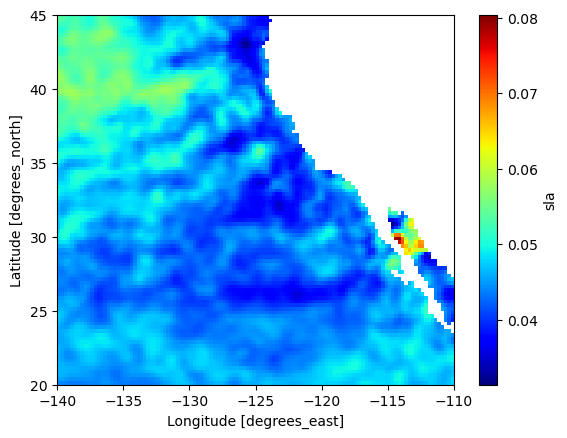

In [15]:
# load AVISO ssh
path = '~/data/'
fname='cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1M-m_1724096981442.nc'
sla = xr.open_dataset(path + fname).sla
sla.mean(dim='time').plot(cmap='jet');

fname='cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D_1724097589568.nc'
ugos, vgos = xr.open_dataset(path + fname).ugos, xr.open_dataset(path + fname).vgos
ssh = xr.open_dataset(path + fname).adt
ssh

In [16]:
# Compute EKE from SSH

def compute_eke(ssh,lats,lons):
    # Convert lat/lon to radians
    lat_rad = np.radians(lats)
    lon_rad = np.radians(lons)
    
    # Constants
    R = 6371000  # Earth's radiusin meters
    g = 9.81  # gravitational acceleration (m/s^2)
    omega = 7.2921e-5  # Earth's rotation rate, rad/s
    f = 2 * omega * np.sin(lat_rad)
    
    
    # Calculate the differences in lat and lon (assumed to be uniform across time)
    dlat = np.gradient(lat_rad, axis=0)  # change in lat
    dlon = np.gradient(lon_rad, axis=1)  # change in lon
    
    # Calculate the spacing in meters
    dx = R * np.cos(lat_rad) * dlon  # zonal distance
    dy = R * dlat                    # meridional distance
    
    # Initialize arrays for u_g and v_g
    u_g = np.empty_like(ssh)
    v_g = np.empty_like(ssh)
    
    # Loop over ocean_time to compute the gradients and velocities
    for t in range(ssh.shape[0]):
        # Compute the gradients for the current time step
        dzeta_dy = np.gradient(ssh[t], axis=0) / dy  # meridional gradient
        dzeta_dx = np.gradient(ssh[t], axis=1) / dx  # zonal gradient
    
        # Geostrophic velocities for the current time step
        u_g[t] = -(g / f) * dzeta_dy
        v_g[t] = (g / f) * dzeta_dx
    
    u_prime = u_g - np.nanmean(u_g,0)
    v_prime = v_g - np.nanmean(v_g,0)
    
    # Calculate EKE
    eke = 0.5 * (u_prime**2 + v_prime**2)
    
    return eke

ssh_aviso = ssh
lons_aviso,lats_aviso = np.meshgrid(ssh.longitude,ssh.latitude)
eke_aviso= compute_eke(ssh_aviso,lats_aviso,lons_aviso)

# Create dataset
EKE_da = xr.DataArray(
    data=eke_aviso,
    dims=["time", "lat", "lon"],
    coords={
        "time": ssh.time.values,  # assuming u has an ocean_time coordinate
        "lat": ssh.latitude.values,
        "lon": ssh.longitude.values,
    },
    name="EKE"
)

# Create Dataset
EKE = xr.Dataset({"EKE": EKE_da})
EKE

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_93134/404943114.py:37: RuntimeWarning: Mean of empty slice
  u_prime = u_g - np.nanmean(u_g,0)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_93134/404943114.py:38: RuntimeWarning: Mean of empty slice
  v_prime = v_g - np.nanmean(v_g,0)


<xarray.Dataset> Size: 157MB
Dimensions:  (time: 10958, lat: 64, lon: 56)
Coordinates:
  * time     (time) datetime64[ns] 88kB 1993-06-07 1993-06-08 ... 2023-06-07
  * lat      (lat) float32 256B 28.12 28.38 28.62 28.88 ... 43.38 43.62 43.88
  * lon      (lon) float32 224B -129.9 -129.6 -129.4 ... -116.6 -116.4 -116.1
Data variables:
    EKE      (time, lat, lon) float32 157MB 0.0004389 0.0004522 ... nan nan

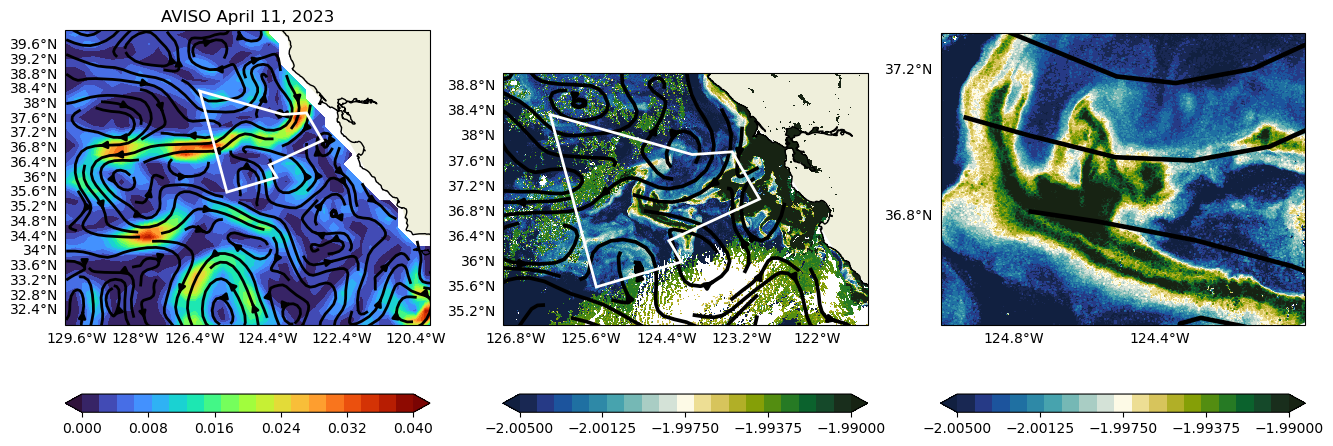

In [17]:
## EKE + CHL + ZOOM IN
eke_apr2311 = EKE.sel(time='2023-04-11',method='nearest').EKE
ugos_apr2311 = ugos.sel(time='2023-04-11',method='nearest')
vgos_apr2311 = vgos.sel(time='2023-04-11',method='nearest')

fig,axes = plt.subplots(1,3,figsize=(16,6), subplot_kw={'projection': ccrs.PlateCarree()})
cmap='turbo'
levels=np.linspace(0,0.04,20)

# EKE April 11, 2023
ax=axes[0]
p=ax.contourf(lons_aviso,lats_aviso,eke_apr2311,levels=levels,cmap=cmap,extend='both')
plt.colorbar(p,ax=ax,ticks=np.arange(levels[0],levels[-1]+0.002,0.008),orientation='horizontal')
ax.set_title('AVISO April 11, 2023')

# Chl April 11, 2023
ax=axes[1]
p=ax.contourf(sen3.lon,sen3.lat,sen3.CHL_OC4ME,np.linspace(-2.005,-1.99,20),cmap=cm.delta,extend='both')
plt.colorbar(p,ax=ax,ticks=np.linspace(-2.005,-1.99,5),orientation='horizontal')

# Chl Zoom in
ax=axes[2]
p=ax.contourf(sen3.lon,sen3.lat,sen3.CHL_OC4ME,np.linspace(-2.005,-1.99,20),cmap=cm.delta,extend='both')
plt.colorbar(p,ax=ax,ticks=np.linspace(-2.005,-1.99,5),orientation='horizontal')

for i,ax in enumerate(axes):
    ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', linewidth=2*(i/3+1), density=2,zorder=1)
    #coastline(ax,lw=2,c='k')
    smode_pgon(ax,lw=2,c='w')

axes[0].set_xlim(-129.9,-120); axes[0].set_ylim(32,40)
axes[1].set_xlim(-127,-121.2); axes[1].set_ylim(35,39)
#axes[2].set_xlim(-124.8,-123.2); axes[2].set_ylim(36.,37.5)
axes[2].set_xlim(-125,-124.); axes[2].set_ylim(36.5,37.3)

for axis in axes:
    gl = axis.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gridlines(gl)
    axis.add_feature(cfeature.LAND.with_scale('110m'))
    axis.add_feature(cfeature.COASTLINE)
plt.show();


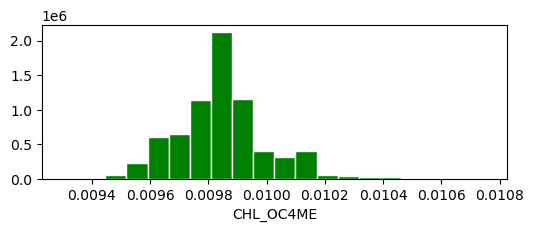

In [113]:
(10**(sen3.CHL_OC4ME)).plot.hist(bins=20,color='g',edgecolor='w',figsize=(6,2));

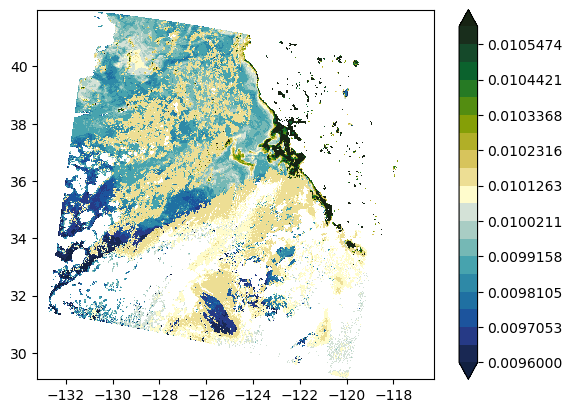

In [18]:
plt.contourf(
    sen3.lon, sen3.lat, 10**sen3.CHL_OC4ME,np.linspace(0.0096,0.0106,20),
    cmap=cm.delta, extend='both')
plt.colorbar()

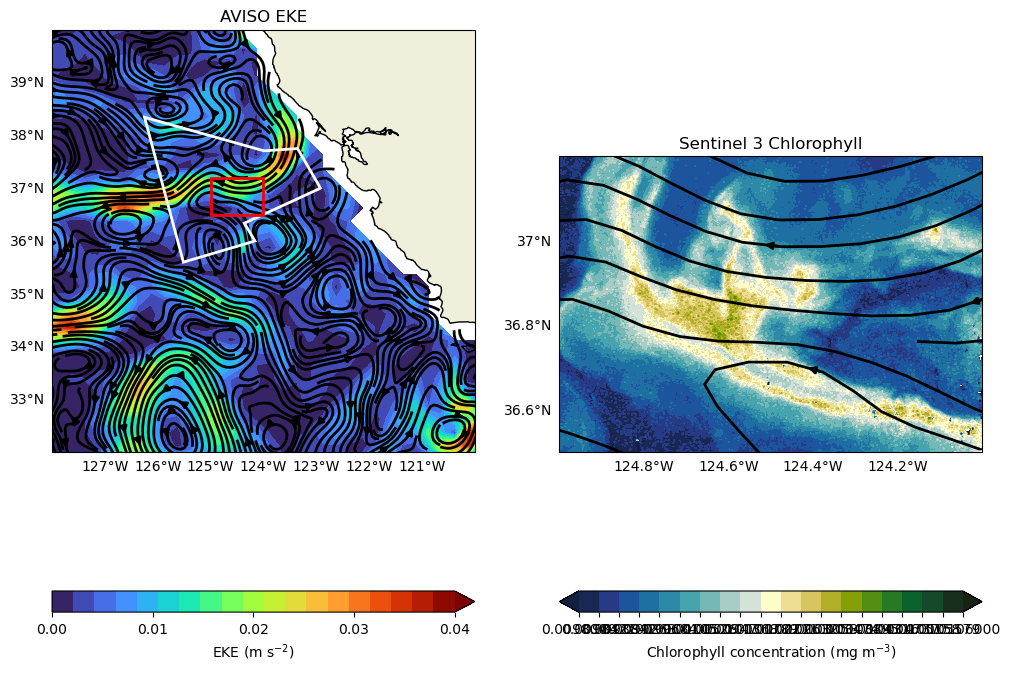

In [21]:
## EKE + CHL + ZOOM IN
import matplotlib.patches as patches

eke_apr2311 = EKE.sel(time='2023-04-11',method='nearest').EKE
ugos_apr2311 = ugos.sel(time='2023-04-11',method='nearest')
vgos_apr2311 = vgos.sel(time='2023-04-11',method='nearest')


# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,12), subplot_kw={'projection': ccrs.PlateCarree()})

# EKE April 11, 2023
ax=axes[0]
p=ax.contourf(lons_aviso,lats_aviso,eke_apr2311,levels=np.linspace(0,0.04,20),cmap='turbo',extend='max')
cbar=plt.colorbar(p,ax=ax,ticks=np.arange(levels[0],levels[-1]+0.002,0.008),orientation='horizontal')
cbar.set_label('EKE (m s$^{-2})$')
cbar.set_ticks(np.linspace(0,0.04,5))
ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', linewidth=2, density=6, zorder=1)
ax.set_title('AVISO EKE')
ax.set_xlim(-128,-120); ax.set_ylim(32,40)

square = patches.Rectangle(
    (-125, 36.5),  
    1,              # width in degrees
    0.7,              # height in degrees
    linewidth=2, edgecolor='red', facecolor='none', zorder=2
)
ax.add_patch(square)

# Chl Zoom in
ax=axes[1]
p = ax.contourf(
    sen3.lon, sen3.lat, 10**sen3.CHL_OC4ME, np.linspace(0.0098,0.0106,20),
    cmap=cm.delta, extend='both')
cbar=plt.colorbar(p,ax=ax,orientation='horizontal')
cbar.set_label('Chlorophyll concentration (mg m$^{-3})$')
cbar.set_ticks(np.linspace(0.0098,0.0106,20))
ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', linewidth=2, density=6, zorder=1)
ax.set_xlim(-125,-124.); ax.set_ylim(36.5,37.2)
ax.set_title('Sentinel 3 Chlorophyll')

for axis,delta in zip(axes,[1,0.2]):
    smode_pgon(axis,lw=2,c='w')
    gl = axis.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gridlines(gl,delta=delta)
    axis.add_feature(cfeature.LAND)
    axis.add_feature(cfeature.COASTLINE)

    #axis.set_xticksparams(fontsize=16)

#plt.savefig('/Users/elise/Desktop/fig1_python.png',dpi=800)
plt.show()



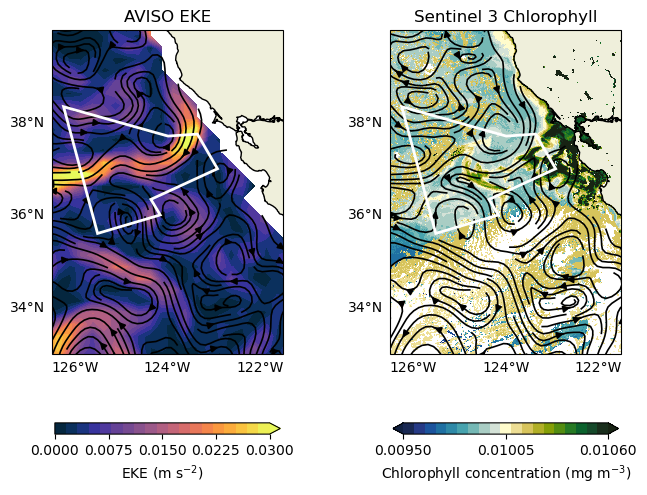

In [60]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create the figure and a GridSpec layout
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1])  # Three columns, two rows

# Plot 1: EKE of the CCS on April 11, 2023
ax1 = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())  # Occupies both rows in the left column
p=ax1.contourf(lons_aviso,lats_aviso,eke_apr2311,levels=np.linspace(0,0.03,20),cmap=cm.thermal,extend='max')
cbar=plt.colorbar(p,ax=ax1,ticks=np.arange(levels[0],levels[-1]+0.002,0.008),orientation='horizontal',shrink=0.8)
cbar.set_label('EKE (m s$^{-2})$')
cbar.set_ticks(np.linspace(0,0.03,5))
ax1.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', linewidth=1.2, density=4, zorder=1)
ax1.set_title('AVISO EKE')

# Plot 2: Chlorophyll concentration of the CCS on April 11, 2023
ax2 = fig.add_subplot(gs[:, 1], projection=ccrs.PlateCarree())
p = ax2.contourf(sen3.lon, sen3.lat, 10**sen3.CHL_OC4ME, np.linspace(0.0095,0.0106,20), cmap=cm.delta, extend='both')
cbar=plt.colorbar(p,ax=ax2,orientation='horizontal',shrink=0.8)
cbar.set_label('Chlorophyll concentration (mg m$^{-3})$')
cbar.set_ticks(np.linspace(0.0095,0.0106,3))
ax2.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', linewidth=1.2, density=4, zorder=1)
ax2.set_title('Sentinel 3 Chlorophyll')

for axis in (ax1, ax2):
    axis.set_xlim(-126.5,-121.5); axis.set_ylim(33,40)
    gl = axis.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gridlines(gl,delta=2)
    axis.add_feature(cfeature.LAND)
    axis.add_feature(cfeature.COASTLINE)
    smode_pgon(axis,lw=2,c='w')

plt.savefig('/Users/elise/Desktop/fig1ab.png',dpi=800, bbox_inches='tight', transparent=True,)
#plt.tight_layout()
plt.show()


NameError: name 'lons_aviso' is not defined

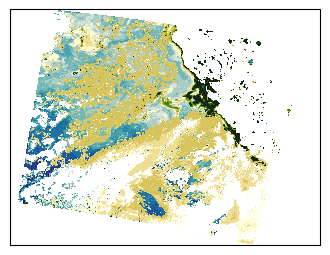

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create the figure and a GridSpec layout with two rows, one column
fig = plt.figure(figsize=(4, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 2])  # One column, two rows with equal height

# Plot 3: Zoom in on Chlorophyll concentration
ax3 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
p = ax3.contourf(sen3.lon, sen3.lat, 10**sen3.CHL_OC4ME, np.linspace(0.0095, 0.0106, 20), cmap=cm.delta, extend='both')
ax3.streamplot(lons_aviso, lats_aviso, ugos_apr2311, vgos_apr2311, color='k', linewidth=2, density=4, zorder=1)
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
gridlines(gl,delta=0.4)
ax3.set_ylim(36, 37.5)
ax3.set_title('')
ax3.add_feature(cfeature.LAND)
ax3.add_feature(cfeature.COASTLINE)
ax3.scatter(dataset.lon, dataset.lat, marker='o', edgecolors='k', s=20, zorder=101)
smode_pgon(ax3,lw=2,c='w')

# Plot 4: Chlorophyll Rate of Change per Longitude
rounded_lons = np.round(dataset.lon / 0.1) * 0.1
unique_rounded_lons = np.unique(rounded_lons)
dChldt_by_lon_group = [dataset.dChldt[rounded_lons == lon] for lon in unique_rounded_lons]

ax4 = fig.add_subplot(gs[1, 0], sharex=ax3)  # sharex=ax3 for consistent longitude scaling
#ax4.scatter(dataset.lon, dataset.dChldt, s=20, edgecolor='lightgreen', c=None, marker='o', color='limegreen', zorder=101)
ax4.boxplot(dChldt_by_lon_group, positions=unique_rounded_lons, widths=0.1, patch_artist=True,
            boxprops=dict(facecolor="limegreen", color="lightgreen"),
            medianprops=dict(color="black"))
ax4.axhline(0, color='k', linestyle=':')
ax4.grid(alpha=0.3)
ax4.set_title("Chlorophyll Rate of Change")
ax4.set_xlabel('Longitude')
ax4.set_xticks([])

for axis in (ax3, ax4):
    axis.set_xlim(-126, -123.5)
#plt.savefig('/Users/elise/Desktop/fig1cd.png',dpi=800, bbox_inches='tight', transparent=True,)
#plt.tight_layout()
plt.show()


In [5]:
# TSG
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

def interp_ship_on_drifter_ASC(TSG, drifter, resample, dist=1):
        
    # chlorohypll flowrate control
    flowrate_okay = np.where(TSG.flowrate_time_bio>1.)

    # Resample data
    TSG_longitude   = TSG.longitude_bio.resample(time_bio=resample).mean()
    TSG_latitude    = TSG.latitude_bio.resample(time_bio=resample).mean()
    TSG_chlorophyll = TSG.chlorophyll_ACS[flowrate_okay].resample(time_bio=resample).mean()
    
    # Interpolate ship data onto drifter time
    interp_lon = TSG_longitude.interp(time_bio=drifter.time, method='linear')
    interp_lat = TSG_latitude.interp(time_bio=drifter.time, method='linear')
    interp_chl = TSG_chlorophyll.interp(time_bio=drifter.time, method='linear')
    
    # Save chlorophyll values when dist < 1 km
    distances = haversine(drifter.latitude, drifter.longitude, interp_lat, interp_lon) # pairwise distances
    idx = (distances <= dist)
    
    # Logarithmic chlorophyll rate of change
    # dP/dt = P2 * log(P2/P1) / dt
    dChldt_ship = np.empty(len(drifter.time[idx]))*np.nan
    P1,P2 = interp_chl[idx][:-1].values, interp_chl[idx][1:].values
    dChl = P2 * np.log(P2/P1)
    dt   = (drifter.time[idx].diff(dim='time')*1e-9).astype(float) # seconds
    #print(dChldt_ship.shape,dChl.shape,dt.shape)
    dt   = dt/86400. # convert to day
    dChldt_ship[1::] = dChl/dt
    
    dataset = xr.Dataset(
    {
        'lon': ('time', drifter.longitude[idx].values),
        'lat': ('time', drifter.latitude[idx].values),
        'chl': ('time', interp_chl[idx].values),
        'dChldt': ('time', dChldt_ship),
    },
    coords={'time': drifter.time[idx].values},
    attrs={'name': drifter.title[-7::]},
    )
    
    return dataset
    

In [6]:
# drifters data
SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))
if not dr_files: print('No files found')

# underway ship data
uw = xr.open_dataset(SMODE_DATA_folder+'TSG/'+'IOP2_underway.nc')

times   = []
lats    = []
lons    = []
dChldts = []
chls    = []

uw_resampled = uw.resample(time='4h').mean(dim='time')

for file in dr_files:
    drifter = xr.open_dataset(file)
    drifter = drifter.isel(time=drifter.position_QCflag==1)

    resample='4h'
    dr = interp_ship_on_drifter_ASC(TSG, drifter, resample, dist=1)
    if len(dr.time)>0:
        dr = dr.resample(time='1h').mean(dim='time')

    times.append(dr.time.values)
    lats.append(dr.lat.values)
    lons.append(dr.lon.values)
    dChldts.append(dr.dChldt.values)
    chls.append(dr.chl.values)
    
times = np.concatenate(times)
lats = np.concatenate(lats)
lons = np.concatenate(lons)
dChldts = np.concatenate(dChldts)
chls = np.concatenate(chls)

In [7]:
dataset = xr.Dataset(
    {
        'lon': ('time', lons),
        'lat': ('time', lats),
        'chl': ('time', chls),
        'dChldt': ('time', dChldts),
    },
    coords={'time': times},
    attrs={'name': 'Chlorophyll Rates of Change from a Lagrangian Framework'},
    )
dataset

<xarray.Dataset> Size: 50kB
Dimensions:  (time: 1247)
Coordinates:
  * time     (time) datetime64[ns] 10kB 2023-04-30T23:00:00 ... 2023-04-22T12...
Data variables:
    lon      (time) float64 10kB -125.5 -125.5 -124.0 -124.1 ... nan nan -124.1
    lat      (time) float64 10kB 36.86 36.86 36.97 36.96 ... nan nan nan 36.9
    chl      (time) float64 10kB 1.312 1.349 1.817 1.869 ... nan nan nan 2.954
    dChldt   (time) float64 10kB 1.923 0.732 2.756 2.755 ... nan nan nan -6.162
Attributes:
    name:     Chlorophyll Rates of Change from a Lagrangian Framework

In [9]:
dataset.to_netcdf('dChldts.nc')

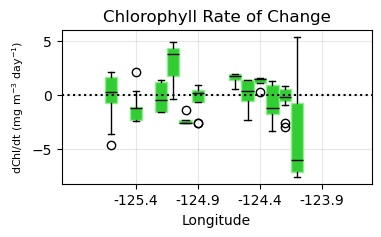

In [11]:
# Plot 4: Chlorophyll Rate of Change per Longitude
import matplotlib.pyplot as plt
import xarray as xr
dataset=xr.open_dataset('dChldts.nc')

plt.rcParams["pdf.fonttype"] = 42

fig, ax4 = plt.subplots(1,1,figsize=(4,2))

dlon=0.1
rounded_lons = np.round(dataset.lon / dlon) * dlon
unique_rounded_lons = np.unique(rounded_lons)
dChldt_by_lon_group = [dataset.dChldt[rounded_lons == lon] for lon in unique_rounded_lons]

#ax4 = fig.add_subplot(gs[1, 0], sharex=ax3)  # sharex=ax3 for consistent longitude scaling
#ax4.scatter(dataset.lon, dataset.dChldt, s=20, edgecolor='lightgreen', c=None, marker='o', color='limegreen', zorder=101)
ax4.boxplot(dChldt_by_lon_group, positions=unique_rounded_lons, widths=dlon, patch_artist=True,
            boxprops=dict(facecolor="limegreen", color="lightgreen"),
            medianprops=dict(color="black"))
ax4.axhline(0, color='k', linestyle=':')
ax4.grid(alpha=0.3)
ax4.set_title("Chlorophyll Rate of Change")
ax4.set_xlabel('Longitude')
ax4.set_xticks(np.round(np.arange(-125.4,-123,0.5),1),np.round(np.arange(-125.4,-123,0.5),1))
#ax4.set_xticks(ax4.get_xticks()[::18], np.round(ax4.get_xticks(),1)[::18])#, rotation = 24) 

ax4.set_xlim(-126, -123.5)
ax4.set_ylabel('dChl/dt (mg m$^{-3}$ day$^{-1}$)',fontsize=8)

#plt.savefig('/Users/elise/Desktop/fig1cd.png',dpi=800, bbox_inches='tight', transparent=True,)
#plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig2/fig2c.pdf')
#plt.tight_layout()
plt.show()

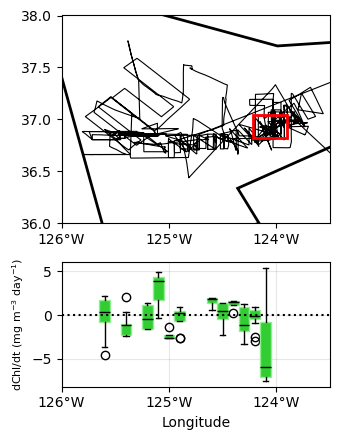

In [108]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2,1, figsize=(3.5, 4.5), height_ratios=[5,3])#, sharex=True)

# Shiptrack subplot
ax=axes[0]
ax.plot(uw.lon, uw.lat, '-k', alpha=1, lw=0.8, zorder=0)

lon_min, lon_max = -124.22, -123.9
lat_min, lat_max = 36.82, 37.04

# Add rectangle for region of interest
square = Rectangle(
    (lon_min, lat_min),  # Bottom-left corner
    lon_max - lon_min,   # Width
    lat_max - lat_min,   # Height
    linewidth=2, edgecolor='red', facecolor='none'
)
ax.add_patch(square)
ax.set_ylim(36, 38)
smode_pgon(ax, lw=2)

# dChldt
ax4=axes[1]
dlon=0.1
rounded_lons = np.round(dataset.lon / dlon) * dlon
unique_rounded_lons = np.unique(rounded_lons)
dChldt_by_lon_group = [dataset.dChldt[rounded_lons == lon] for lon in unique_rounded_lons]

ax4.boxplot(dChldt_by_lon_group, positions=unique_rounded_lons, widths=dlon, patch_artist=True,
            boxprops=dict(facecolor="limegreen", color="lightgreen"),
            medianprops=dict(color="black"))
ax4.axhline(0, color='k', linestyle=':')
ax4.grid(alpha=0.3)
#ax4.set_title("Chlorophyll Rate of Change")
ax4.set_xlabel('Longitude')
ax4.set_xticks(np.round(np.arange(-125.4,-123,0.5),1),np.round(np.arange(-125.4,-123,0.5),1))
ax4.set_ylabel('dChl/dt (mg m$^{-3}$ day$^{-1}$)',fontsize=8)

#plt.savefig('/Users/elise/Desktop/fig1cd.png',dpi=800, bbox_inches='tight', transparent=True,)

for axis in axes:
    axis.set_xlim(-126, -123.5)
    xticks = np.round(np.arange(-126, -123, 1), 1)
    axis.set_xticks(xticks)
    axis.set_xticklabels([f"{abs(x):.0f}°W" for x in xticks])

plt.tight_layout()
#plt.savefig('/Users/elise/Desktop/Fig2bc.png',dpi=800, bbox_inches='tight')#, transparent=True)
plt.show()


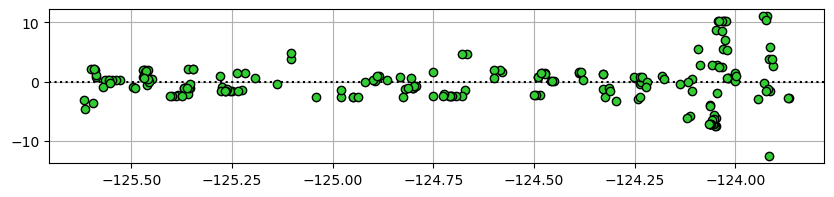

In [53]:
plt.figure(figsize=(10,2))
plt.scatter(dataset.lon, dataset.dChldt, edgecolor='k', marker='o', color='limegreen', zorder=101)
plt.axhline(0,color='k',linestyle=':')
plt.grid()
plt.show()

In [ ]:
dataset.

## Other stuff

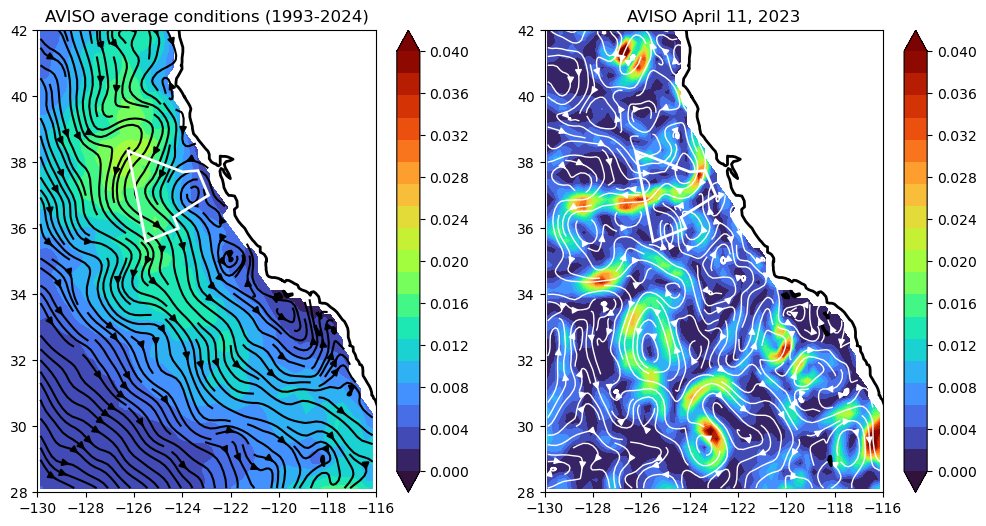

In [1040]:
from cmocean import cm

fig,axes = plt.subplots(1,2,figsize=(6*2,6))
cmap_name='tarn'
cmap=getattr(cm, cmap_name)#'ocean_r'#'turbo'
cmap='turbo'
levels=np.linspace(0,0.04,20)

# AVISO
eke_mean = EKE.EKE.mean(dim='time')
eke_clim = EKE.EKE.groupby('time.month').mean()
eke_clim_apr = eke_clim.sel(month=4-1)
eke_apr23 = EKE.sel(time='2023-04',method='nearest').EKE
eke_apr2311 = EKE.sel(time='2023-04-11',method='nearest').EKE

ugos_mean = ugos.mean(dim='time')
vgos_mean = vgos.mean(dim='time')
ugos_clim = ugos.groupby('time.month').mean()
vgos_clim = vgos.groupby('time.month').mean()
ugos_clim_apr = ugos_clim.sel(month=4-1)
vgos_clim_apr = vgos_clim.sel(month=4-1)
ugos_apr2311 = ugos.sel(time='2023-04-11',method='nearest')
vgos_apr2311 = vgos.sel(time='2023-04-11',method='nearest')

# Average April conditions
ax=axes[0]
p=ax.contourf(lons_aviso,lats_aviso,eke_mean,levels=levels,cmap=cmap,extend='both')
plt.colorbar(p,ax=ax,ticks=np.arange(levels[0],levels[-1]+0.002,0.004))
#ax.contour(lons_aviso,lats_aviso,ssh_aviso.mean(dim='time'),20,colors='k',extend='both')
ax.streamplot(lons_aviso,lats_aviso,ugos_mean,vgos_mean, color='k', density=2,zorder=1)
ax.set_title('AVISO average conditions (1993-2024)')

# April 11, 2023
ax=axes[1]
p=ax.contourf(lons_aviso,lats_aviso,eke_apr2311,levels=levels,cmap=cmap,extend='both')
plt.colorbar(p,ax=ax,ticks=np.arange(levels[0],levels[-1]+0.002,0.004))
#ax.contour(lons_aviso,lats_aviso,ssh_aviso.mean(dim='time'),20,colors='k',extend='both')
ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='w', linewidth=1, density=2,zorder=1)
ax.set_title('AVISO April 11, 2023')

for ax in axes:
    coastline(ax,lw=2,c='k')
    smode_pgon(ax,lw=2,c='w')
    ax.set_xlim(-130,-116); ax.set_ylim(28,42)

#plt.savefig(f'/Users/elise/Desktop/EKE_{cmap_name}.png',dpi=800)
plt.show();


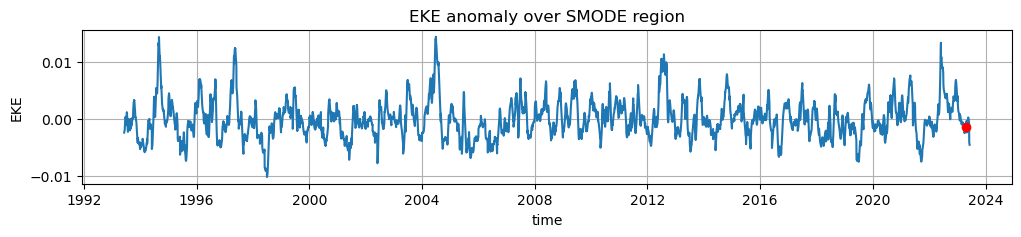

In [28]:
EKE_smode = EKE.EKE.sel(lat=slice(35,39),lon=slice(-126,-122)).mean(dim=['lat','lon'])
#EKE_smode = EKE.EKE.sel(lat=slice(30,45),lon=slice(-132,-124)).mean(dim=['lat','lon'])
EKE_clim  = EKE_smode.groupby('time.month').mean('time')
EKE_ano   = EKE_smode.groupby('time.month') - EKE_clim

plt.figure(figsize=(12,2))
EKE_ano.plot()
plt.plot(pd.Timestamp('2023-04-15'),EKE_ano.sel(time='2023-04').mean(dim='time'),'or')

plt.grid()
plt.title("EKE anomaly over SMODE region")
plt.show();

In [51]:
# drifters data
SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))
if not dr_files: print('No files found')

# underway ship data
uw = xr.open_dataset(SMODE_DATA_folder+'TSG/'+'IOP2_underway.nc')
uw

<xarray.Dataset> Size: 9MB
Dimensions:  (time: 146934)
Coordinates:
  * time     (time) datetime64[ns] 1MB 2023-04-07T18:54:10.000004 ... 2023-05...
Data variables:
    lat      (time) float64 1MB ...
    lon      (time) float64 1MB ...
    chl      (time) float64 1MB ...
    temp     (time) float64 1MB ...
    salt     (time) float64 1MB ...
    rho      (time) float64 1MB ...
    o2sat    (time) float64 1MB ...

In [15]:
def interp_ship_on_drifter(underway_data, drifter, dist=1):
    from scipy.interpolate import interp1d
    # drifter data
    time_dr= drifter.time
    lat_dr = drifter.latitude
    lon_dr = drifter.longitude

    def is_night(timestamp,delta=-7): #account for photochemical quenching
        # UTC to PST delta=-7
        return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
    
    def interpolate_function(time_dr,time_uw,variable):
        num_time_uw      = time_uw.astype('int64') / 1e9 # nanoseconds to seconds
        num_time_drifter = time_dr.astype('int64') / 1e9
        interp_function  = interp1d(num_time_uw, variable, kind='linear',fill_value=np.nan, bounds_error=False)
        interpolated_data= interp_function(num_time_drifter)
        return interpolated_data
        
    # Interpolate ship data onto drifter time
    interp_lon = interpolate_function(time_dr,underway_data.time,underway_data.lon)
    interp_lat = interpolate_function(time_dr,underway_data.time,underway_data.lat)
    interp_chl = interpolate_function(time_dr,underway_data.time,underway_data.chl)
    interp_temp = interpolate_function(time_dr,underway_data.time,underway_data.temp)
    interp_salt = interpolate_function(time_dr,underway_data.time,underway_data.salt)
    interp_rho = interpolate_function(time_dr,underway_data.time,underway_data.rho)
    interp_o2sat = interpolate_function(time_dr,underway_data.time,underway_data.o2sat)
    
    # Save chlorophyll values when dist < 1 km  & nighttime
    distances = haversine(lat_dr, lon_dr, interp_lat, interp_lon) # pairwise distances
    idx = (distances <= dist) & (is_night(time_dr))
    
    # Logarithmic chlorophyll rate of change
    # dP/dt = P2 * log(P2/P1) / dt
    dChldt_ship = np.empty(len(drifter.time[idx]))*np.nan
    P1,P2 = interp_chl[idx][:-1].values, interp_chl[idx][1:].values
    dChl = P2 * np.log(P2/P1)
    dt   = (drifter.time[idx].diff(dim='time')*1e-9).astype(float) # seconds
    #print(dChldt_ship.shape,dChl.shape,dt.shape)
    dt   = dt/86400. # convert to day
    dChldt_ship[1::] = dChl/dt

    # dSSSdt
    dSSSdt_ship = np.empty(len(time_dr[idx]))*np.nan
    dSSS = np.diff(interp_salt[idx]) # mg m-3
    dSSSdt_ship[1::] = dSSS/dt

    # dSSTdt
    dSSTdt_ship = np.empty(len(time_dr[idx]))*np.nan
    dSST = np.diff(interp_temp[idx]) # mg m-3
    dSSTdt_ship[1::] = dSST/dt
    
    dataset = xr.Dataset(
    {
        'lon': ('time', lon_dr[idx].values),
        'lat': ('time', lat_dr[idx].values),
        'chl': ('time', interp_chl[idx]),
        'temp': ('time', interp_temp[idx]),
        'salt': ('time', interp_salt[idx]),
        'rho': ('time', interp_rho[idx]),
        'o2sat': ('time', interp_o2sat[idx]),
        'dChldt': ('time', dChldt_ship),
        'dSSSdt': ('time', dSSSdt_ship),
        'dSSTdt': ('time', dSSTdt_ship),
    },
    coords={'time': time_dr[idx].values},
    attrs={'name': drifter.title[-7::]},
    )
    
    return dataset

In [612]:
times   = []
lats    = []
lons    = []
dChldts = []
dSSSdts = []
dSSTdts = []

uw_resampled = uw.resample(time='4h').mean(dim='time')

for file in dr_files:
    drifter = xr.open_dataset(file)
    drifter = drifter.isel(time=drifter.position_QCflag==1)
    
    dr = interp_ship_on_drifter(uw_resampled, drifter, dist=1)

    times.append(dr.time.values)
    lats.append(dr.lat.values)
    lons.append(dr.lon.values)
    dChldts.append(dr.dChldt.values)
    dSSSdts.append(dr.dSSSdt.values)
    dSSTdts.append(dr.dSSTdt.values)
    
times = np.concatenate(times)
lats = np.concatenate(lats)
lons = np.concatenate(lons)
dChldts = np.concatenate(dChldts)
dSSSdts = np.concatenate(dSSSdts)
dSSTdts = np.concatenate(dSSTdts)

In [670]:
# create data array
sorted_indices = np.argsort(times) # sort my data with increasing time
sorted_time_array = times[sorted_indices]
sorted_lat_array = lats[sorted_indices]
sorted_lon_array = lons[sorted_indices]
sorted_dChldt_array = dChldts[sorted_indices]
sorted_dSSSdt_array = dSSSdts[sorted_indices]
sorted_dSSTdt_array = dSSTdts[sorted_indices]

def create_dataArray(var,varname,description):
    dataArray = xr.DataArray(
                    data=var,
                    dims=['time'],
                    coords=dict(time=sorted_time_array),
                    attrs=dict(
                        description=description,
                        variable=varname,
                    ),
                )
    return dataArray
dataArray1=create_dataArray(sorted_dChldt_array,'dChldt','Chlorophyll rate of change [day-1]')
dataArray2=create_dataArray(sorted_lon_array,'lon','longitude [degrees]')
dataArray3=create_dataArray(sorted_lat_array,'lat','latitude [degrees]')
dataArray4=create_dataArray(sorted_dSSSdt_array,'dSSSdt','Salinity rate of change')
dataArray5=create_dataArray(sorted_dSSTdt_array,'dSSTdt','Temperature rate of change')

dChldt_ds = xr.Dataset({'dChldt': dataArray1, 
                        'lon': dataArray2, 
                        'lat': dataArray3, 
                        'dSSSdt': dataArray4,
                        'dSSTdt': dataArray5})

# clean
threshold = 0.2
condition = ((np.abs(dChldt_ds.dSSSdt) <= threshold) &
             (np.abs(dChldt_ds.dSSTdt) <= threshold))
dChldt_ds['dChldt'] = dChldt_ds.dChldt.where(condition)
dChldt_ds['dSSSdt'] = dChldt_ds.dSSSdt.where(condition)
dChldt_ds['dSSTdt'] = dChldt_ds.dSSTdt.where(condition)

dChldt_ds

<xarray.Dataset> Size: 41kB
Dimensions:  (time: 856)
Coordinates:
  * time     (time) datetime64[ns] 7kB 2023-04-18T14:52:20 ... 2023-05-02T07:...
Data variables:
    dChldt   (time) float64 7kB nan nan nan nan nan nan ... nan nan nan nan nan
    lon      (time) float64 7kB -123.9 -123.9 -123.9 ... -125.6 -125.6 -125.6
    lat      (time) float64 7kB 36.94 36.94 36.94 36.94 ... 36.66 36.66 36.66
    dSSSdt   (time) float64 7kB nan nan nan nan nan nan ... nan nan nan nan nan
    dSSTdt   (time) float64 7kB nan nan nan nan nan nan ... nan nan nan nan nan

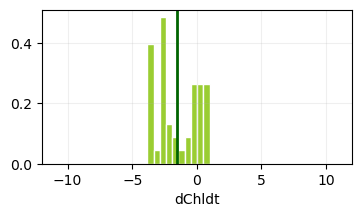

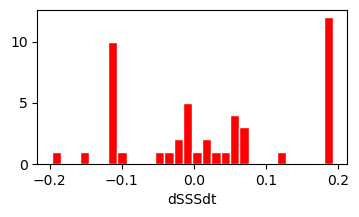

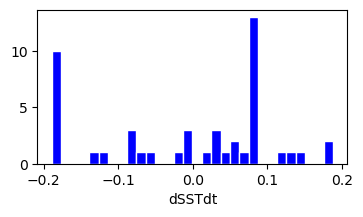

In [672]:
dChldt_ds.dChldt.plot.hist(bins=10,facecolor='yellowgreen',edgecolor='w',figsize=(4,2),density=1);
#plt.axvline(0,color='k',linewidth=0.6)
plt.axvline(np.nanmean(dChldt_ds.dChldt.values),color='darkgreen',linewidth=2)
plt.grid(alpha=0.2)
plt.xlim(-12,12)

dChldt_ds.dSSSdt.plot.hist(bins=30,facecolor='red',edgecolor='w',figsize=(4,2));

dChldt_ds.dSSTdt.plot.hist(bins=30,facecolor='b',edgecolor='w',figsize=(4,2));

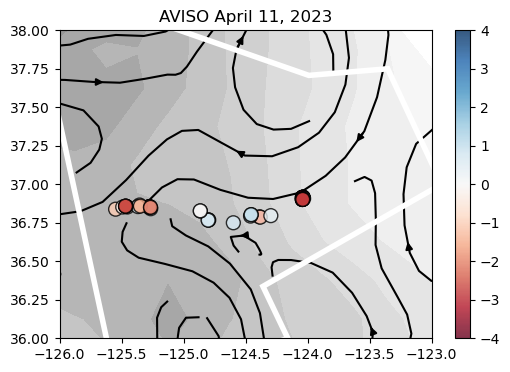

In [674]:
# April 11, 2023
fig,ax=plt.subplots(1,1,figsize=(6,4))
p=ax.contourf(lons_aviso,lats_aviso,eke_mean,levels=levels,cmap='Greys',extend='both')
#plt.colorbar(p,ax=ax,ticks=np.arange(levels[0],levels[-1]+0.002,0.004))

ax.streamplot(lons_aviso,lats_aviso,ugos_apr2311,vgos_apr2311, color='k', density=2,zorder=1)

ax.set_title('AVISO April 11, 2023')

p=ax.scatter(lons,lats,c=dChldt_ds.dChldt,s=100,vmin=-4,vmax=4,edgecolor='k',cmap='RdBu',alpha=0.8)
plt.colorbar(p,ax=ax)

coastline(ax,lw=2)
smode_pgon(ax,c='w',lw=4)
ax.set_xlim(-126,-123); ax.set_ylim(36,38);

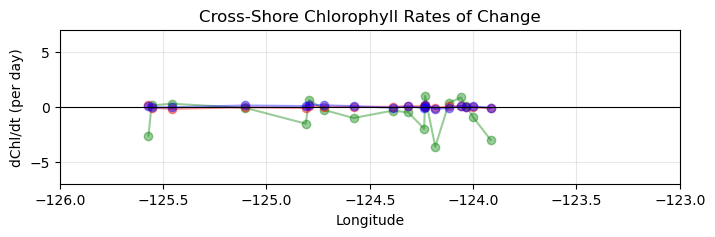

In [712]:
resample='2h'
data = dChldt_ds.resample(time=resample).mean()
data = data.dropna(dim="time", how="any")# remove nans

plt.figure(figsize=(8,2))

plt.plot(data.lon.values,data.dChldt.values,'go-',alpha=0.4,)
plt.plot(data.lon.values,data.dSSSdt.values,'ro-',alpha=0.4,)
plt.plot(data.lon.values,data.dSSTdt.values,'bo-',alpha=0.4,)

plt.axhline(0,color='k',linewidth=0.8)
plt.xticks(np.arange(-126,-122.5,0.5))
plt.ylim(-7,7)
plt.xlabel('Longitude')
plt.ylabel('dChl/dt (per day)')
plt.title('Cross-Shore Chlorophyll Rates of Change')
plt.grid(alpha=0.3);

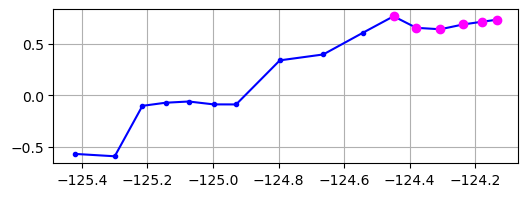

In [942]:
LON=[]
R=[]
P=[]
for i in range(len(data.dSSSdt)):
    x,y = data.dSSTdt.values[i:10+i], data.dChldt.values[i:10+i]
    if len(x)>3:
        r, p = scipy.stats.pearsonr(x, y)
        #if np.abs(r)>0.9: plt.plot(x,y,'.')
        LON.append(data.lon.values[i:10+i].mean())
        R.append(r)
        P.append(p)

LON=np.array(LON)
R=np.array(R)
P=np.array(P)

plt.figure(figsize=(6,2))
plt.plot(LON,  R,'.-b')
threshold=0.05
plt.plot(LON[P<threshold],  R[P<threshold],'o',color='magenta')
plt.grid()

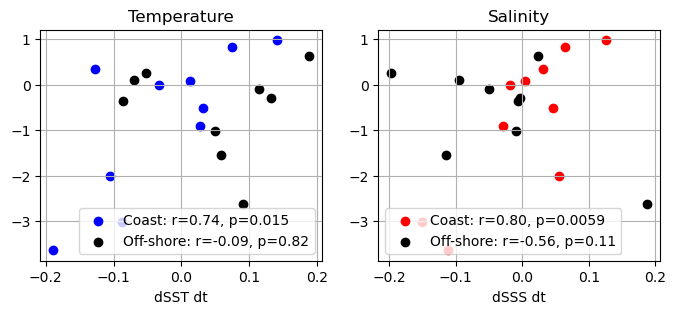

In [888]:
# Correlations coast
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Function to plot scatter with correlation
def plot_scatter(ax, x, y, color, label):
    r, p = scipy.stats.pearsonr(x, y)
    ax.scatter(x, y, color=color, label=f'{label}: r={r:.2f}, p={p:.2g}')
    return ax

# Temperature
ax = plot_scatter(axes[0], data.dSSTdt.values[:10], data.dChldt.values[:10], 'b', 'Coast')
plot_scatter(ax, data.dSSTdt.values[10:], data.dChldt.values[10:], 'k', 'Off-shore')
ax.set_title('Temperature')
ax.set_xlabel('dSST dt')
ax.grid()
ax.legend()

# Salinity
ax = plot_scatter(axes[1], data.dSSSdt.values[:10], data.dChldt.values[:10], 'r', 'Coast')
plot_scatter(ax, data.dSSSdt.values[10:], data.dChldt.values[10:], 'k', 'Off-shore')
ax.set_title('Salinity')
ax.set_xlabel('dSSS dt')
ax.grid()
ax.legend()

plt.show()


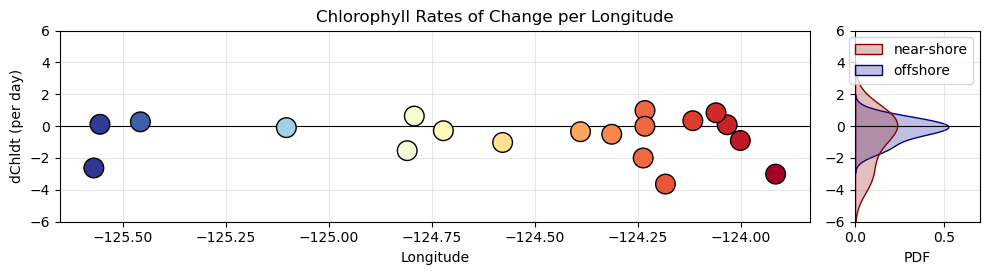

-0.6712513037493519 0.9800060552664992 -3.6377965262127225


In [1243]:
import seaborn as sns

# Creating a figure with two subplots (one for the time series and one for the PDF)
fig = plt.figure(figsize=(10, 3))
gs = fig.add_gridspec(1, 2, width_ratios=[6, 1])

data = dChldt_ds.resample(time=resample).mean()

# Time series plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(data.lon.values,data.dChldt.values,c=data.lon.values,cmap='RdYlBu_r',edgecolor='k',marker='o',s=200,zorder=10)
#ax1.plot(data.lon.values,data.dSSSdt.values,'ro',alpha=0.4,)
#ax1.plot(data.lon.values,data.dSSTdt.values,'bo',alpha=0.4,)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('dChldt (per day)')
ax1.grid(True,alpha=0.3)
ax1.axhline(0,color='k',linewidth=0.8)
#ax1.axhline(np.nanmean(data.dChldt[~np.isnan(data.dChldt)][0:10].values),color='r',linewidth=2)
#ax1.axhline(np.nanmean(data.dChldt[~np.isnan(data.dChldt)][10:-1].values),color='r',linewidth=2)
#ax1.set_ylim(-10,10)

# Vertical PDF plot
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
#sns.kdeplot(y=data.dChldt[~np.isnan(data.dChldt)].values, ax=ax2, fill=True, color='y',zorder=3) # mean 
sns.kdeplot(y=data.dChldt[~np.isnan(data.dChldt)][0:10].values, ax=ax2, fill=True, color='darkred',zorder=2,label='near-shore')# coast
sns.kdeplot(y=data.dChldt[~np.isnan(data.dChldt)][10:-1].values, ax=ax2, fill=True, color='darkblue',zorder=1,label='offshore') # offshore
ax2.set_xlabel('PDF')
ax2.set_ylabel('')  # Remove y-label to avoid redundancy
ax2.grid(True,alpha=0.3)
ax2.axhline(0,color='k',linewidth=0.8)
#ax2.axhline(np.nanmean(data.dChldt),color='r',linewidth=2)
ax2.set_ylim(-6,6)
ax2.legend()
ax2.set_xlim(0,0.7)

plt.suptitle('Chlorophyll Rates of Change per Longitude',y=0.9)
plt.tight_layout()
plt.show();

print(np.nanmean(data.dChldt), data.dChldt.max().values, data.dChldt.min().values)

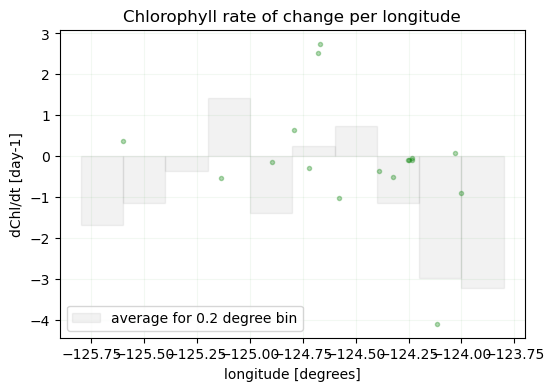

In [431]:
# dChldt per longitude

resample='1h'

bin_width=1/5
lon_bins = np.arange(-126,-123,bin_width)
chl_bins = np.empty(len(lon_bins))

for i in range(len(lon_bins)-1):
    idx = np.where((dChldt_ds.lon.resample(time=resample).mean()>=lon_bins[i]) 
                   & ((dChldt_ds.lon.resample(time=resample).mean()<lon_bins[i+1])))
    
    # Check if the slice is empty or contains only NaNs
    if np.isnan(dChldts[idx]).all():
        chl_bins[i] = np.nan  # or assign a different value if needed
    else:
        chl_bins[i] = np.nanmean(dChldts[idx])

# remove last
lon_bins=lon_bins[0:-1]
chl_bins=chl_bins[0:-1]

plt.figure(figsize=(6,4))
plt.bar(lon_bins+bin_width/2, chl_bins, width=bin_width, 
        color='k',alpha=0.05,edgecolor='k',label=f'average for {bin_width} degree bin')

plt.plot(dChldt_ds.lon.resample(time=resample).mean().values,dChldt_ds.dChldt.resample(time=resample).mean().values,'g.',alpha=0.3)
plt.title('Chlorophyll rate of change per longitude')
plt.ylabel('dChl/dt [day-1]')
#plt.ylim(-4,4)
plt.legend(loc='lower left')
plt.xlabel('longitude [degrees]')
plt.grid(color='g',alpha=0.05)
#plt.savefig('/Users/elise/ocean/drifters_chl/figures/dChldt_per_longitude_resampled_1H.png',dpi=800)
plt.show();

### old stuff

In [ ]:
def smooth_ssh(data):
    import scipy.interpolate as spi
    
    # Select the data for a specific time slice
    #data = ssh.sel(time='2023-04-11', method='nearest')
    
    # Flatten the data for interpolation
    lons, lats = np.meshgrid(data.longitude.values, data.latitude.values)
    x = lons.flatten()
    y = lats.flatten()
    z = data.values.flatten()
    
    # Determine the shape of the original grid
    original_shape = lons.shape
    
    # Create a denser grid for the smoothed data (doubling the resolution)
    xi, yi = np.meshgrid(
        np.linspace(x.min(), x.max(), original_shape[1] * 2),
        np.linspace(y.min(), y.max(), original_shape[0] * 2)
    )
    
    # Apply spline interpolation to the denser grid
    smoothed_data = spi.griddata((x, y), z, (xi, yi), method='linear')
    #plt.contour(lons, lats, data, levels=20, colors='k', linewidths=2)
    #plt.contour(xi, yi, smoothed_data, levels=20, colors='r')
    #coastline(plt.gca())
    #plt.show()
    return xi, yi, smoothed_data